In [1]:
# ============================================================
# BLOQUE 1: Importacion de librerias
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (f1_score, recall_score, precision_score,
                             roc_auc_score, confusion_matrix,
                             precision_recall_curve, roc_curve)
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
pd.set_option('display.float_format', '{:.4f}'.format)

print("Librerias importadas correctamente")

Librerias importadas correctamente


In [2]:
# ============================================================
# BLOQUE 2: Carga de datos procesados
# ============================================================

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print("Datos cargados correctamente")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}  | Positivos: {y_train.sum():,}  | Negativos: {(y_train==0).sum():,}")
print(f"y_test  : {y_test.shape}   | Positivos: {y_test.sum():,}   | Negativos: {(y_test==0).sum():,}")

Datos cargados correctamente
X_train : (60000, 170)
X_test  : (16000, 170)
y_train : (60000,)  | Positivos: 1,000  | Negativos: 59,000
y_test  : (16000,)   | Positivos: 375   | Negativos: 15,625


In [3]:
# ============================================================
# BLOQUE 3: Entrenamiento Random Forest con class weighting
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_validate

print("=" * 60)
print("RANDOM FOREST CON CLASS WEIGHTING")
print("=" * 60)

# Definicion del modelo con class_weight balanced
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Validacion cruzada estratificada (5 folds)
print("\nEjecutando validacion cruzada estratificada (5 folds)...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    rf_model, X_train, y_train,
    cv=cv,
    scoring=['f1', 'recall', 'precision', 'roc_auc'],
    n_jobs=-1
)

print("\nResultados validacion cruzada:")
print(f"  F1       : {cv_results['test_f1'].mean():.4f} (+/- {cv_results['test_f1'].std():.4f})")
print(f"  Recall   : {cv_results['test_recall'].mean():.4f} (+/- {cv_results['test_recall'].std():.4f})")
print(f"  Precision: {cv_results['test_precision'].mean():.4f} (+/- {cv_results['test_precision'].std():.4f})")
print(f"  AUC-ROC  : {cv_results['test_roc_auc'].mean():.4f} (+/- {cv_results['test_roc_auc'].std():.4f})")

# Entrenamiento final sobre todo el train
print("\nEntrenando modelo final sobre todo el conjunto de train...")
rf_model.fit(X_train, y_train)
print("Entrenamiento completado.")

RANDOM FOREST CON CLASS WEIGHTING

Ejecutando validacion cruzada estratificada (5 folds)...

Resultados validacion cruzada:
  F1       : 0.7015 (+/- 0.0315)
  Recall   : 0.5720 (+/- 0.0396)
  Precision: 0.9092 (+/- 0.0129)
  AUC-ROC  : 0.9819 (+/- 0.0046)

Entrenando modelo final sobre todo el conjunto de train...
Entrenamiento completado.


In [4]:
# ============================================================
# BLOQUE 4: Entrenamiento XGBoost con class weighting
# ============================================================

print("=" * 60)
print("XGBOOST CON CLASS WEIGHTING")
print("=" * 60)

# El ratio de desbalance define el scale_pos_weight
# neg/pos = 59000/1000 = 59
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nscale_pos_weight calculado: {scale_pos_weight:.1f}")

# Definicion del modelo
xgb_model = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0
)

# Validacion cruzada estratificada (5 folds)
print("\nEjecutando validacion cruzada estratificada (5 folds)...")

cv_results_xgb = cross_validate(
    xgb_model, X_train, y_train,
    cv=cv,
    scoring=['f1', 'recall', 'precision', 'roc_auc'],
    n_jobs=-1
)

print("\nResultados validacion cruzada:")
print(f"  F1       : {cv_results_xgb['test_f1'].mean():.4f} (+/- {cv_results_xgb['test_f1'].std():.4f})")
print(f"  Recall   : {cv_results_xgb['test_recall'].mean():.4f} (+/- {cv_results_xgb['test_recall'].std():.4f})")
print(f"  Precision: {cv_results_xgb['test_precision'].mean():.4f} (+/- {cv_results_xgb['test_precision'].std():.4f})")
print(f"  AUC-ROC  : {cv_results_xgb['test_roc_auc'].mean():.4f} (+/- {cv_results_xgb['test_roc_auc'].std():.4f})")

# Entrenamiento final sobre todo el train
print("\nEntrenando modelo final sobre todo el conjunto de train...")
xgb_model.fit(X_train, y_train)
print("Entrenamiento completado.")

XGBOOST CON CLASS WEIGHTING

scale_pos_weight calculado: 59.0

Ejecutando validacion cruzada estratificada (5 folds)...

Resultados validacion cruzada:
  F1       : 0.8119 (+/- 0.0175)
  Recall   : 0.8100 (+/- 0.0114)
  Precision: 0.8144 (+/- 0.0309)
  AUC-ROC  : 0.9868 (+/- 0.0022)

Entrenando modelo final sobre todo el conjunto de train...
Entrenamiento completado.


COMPARACION RANDOM FOREST vs XGBOOST

Metrica        Random Forest         XGBoost
---------------------------------------------
F1               0.7015 +/- 0.0315       0.8119 +/- 0.0175
Recall           0.5720 +/- 0.0396       0.8100 +/- 0.0114
Precision        0.9092 +/- 0.0129       0.8144 +/- 0.0309
AUC-ROC          0.9819 +/- 0.0046       0.9868 +/- 0.0022


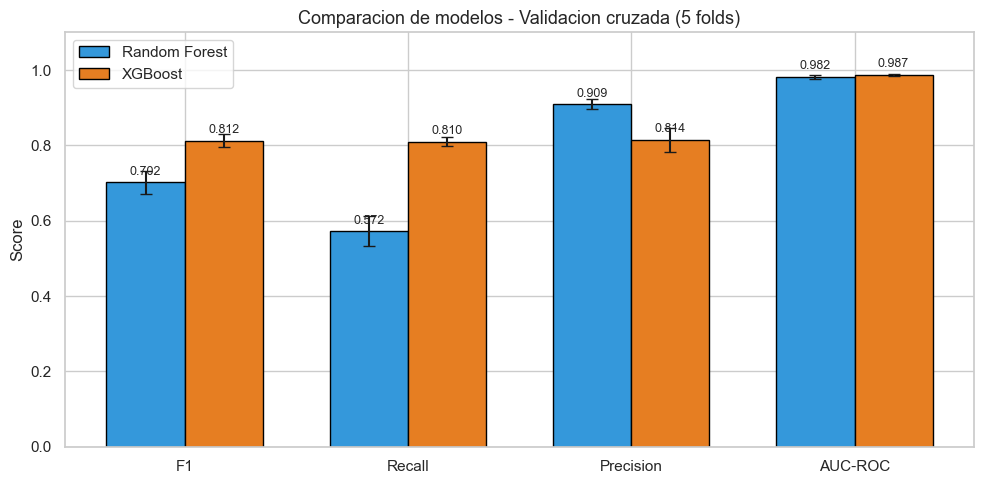

Grafico guardado en outputs/


In [5]:
# ============================================================
# BLOQUE 5: Comparacion de modelos - validacion cruzada
# ============================================================

print("=" * 60)
print("COMPARACION RANDOM FOREST vs XGBOOST")
print("=" * 60)

metricas = ['f1', 'recall', 'precision', 'roc_auc']
labels   = ['F1', 'Recall', 'Precision', 'AUC-ROC']

rf_means  = [cv_results[f'test_{m}'].mean()     for m in metricas]
rf_stds   = [cv_results[f'test_{m}'].std()      for m in metricas]
xgb_means = [cv_results_xgb[f'test_{m}'].mean() for m in metricas]
xgb_stds  = [cv_results_xgb[f'test_{m}'].std()  for m in metricas]

print(f"\n{'Metrica':<12} {'Random Forest':>15} {'XGBoost':>15}")
print("-" * 45)
for i, label in enumerate(labels):
    print(f"{label:<12} {rf_means[i]:>10.4f} +/- {rf_stds[i]:.4f}   {xgb_means[i]:>10.4f} +/- {xgb_stds[i]:.4f}")

# Grafico comparativo
x      = np.arange(len(labels))
width  = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_rf  = ax.bar(x - width/2, rf_means,  width, yerr=rf_stds,  label='Random Forest',
                  color='#3498db', edgecolor='black', capsize=4)
bars_xgb = ax.bar(x + width/2, xgb_means, width, yerr=xgb_stds, label='XGBoost',
                  color='#e67e22', edgecolor='black', capsize=4)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Comparacion de modelos - Validacion cruzada (5 folds)', fontsize=13)
ax.legend()

for bar in bars_rf:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars_xgb:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/03_comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico guardado en outputs/")

AJUSTE DEL UMBRAL DE DECISION

Matriz de costos: FN=500, FP=10, TN=0, TP=0
Umbral teorico de Elkan: 0.0196

Umbral optimo empirico - Random Forest : 0.0248  (costo: 9,700)
Umbral optimo empirico - XGBoost       : 0.0100  (costo: 13,440)


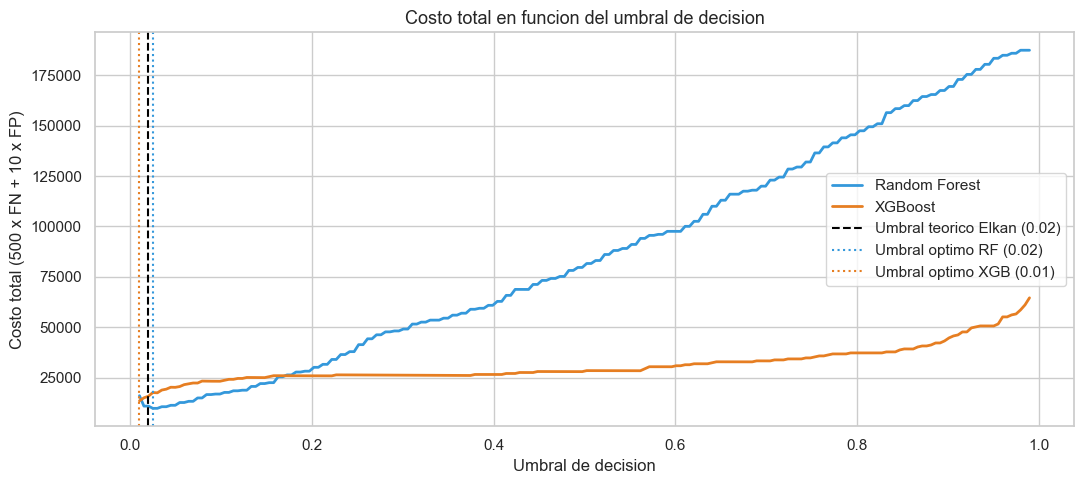

Grafico guardado en outputs/


In [6]:
# ============================================================
# BLOQUE 6: Ajuste del umbral de decision (Elkan)
# ============================================================

print("=" * 60)
print("AJUSTE DEL UMBRAL DE DECISION")
print("=" * 60)

# Umbral teorico de Elkan
C_FN = 500
C_FP = 10
C_TN = 0
C_TP = 0

umbral_teorico = (C_FP - C_TN) / (C_FP - C_TN + C_FN - C_TP)
print(f"\nMatriz de costos: FN={C_FN}, FP={C_FP}, TN={C_TN}, TP={C_TP}")
print(f"Umbral teorico de Elkan: {umbral_teorico:.4f}")

# Probabilidades sobre el conjunto de test
prob_rf  = rf_model.predict_proba(X_test)[:, 1]
prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Curva de costo total en funcion del umbral
umbrales = np.linspace(0.01, 0.99, 200)

costos_rf  = []
costos_xgb = []

for u in umbrales:
    # Random Forest
    pred_rf = (prob_rf >= u).astype(int)
    fn_rf   = ((pred_rf == 0) & (y_test == 1)).sum()
    fp_rf   = ((pred_rf == 1) & (y_test == 0)).sum()
    costos_rf.append(C_FN * fn_rf + C_FP * fp_rf)

    # XGBoost
    pred_xgb = (prob_xgb >= u).astype(int)
    fn_xgb   = ((pred_xgb == 0) & (y_test == 1)).sum()
    fp_xgb   = ((pred_xgb == 1) & (y_test == 0)).sum()
    costos_xgb.append(C_FN * fn_xgb + C_FP * fp_xgb)

# Umbral optimo empirico para cada modelo
idx_rf  = np.argmin(costos_rf)
idx_xgb = np.argmin(costos_xgb)

umbral_opt_rf  = umbrales[idx_rf]
umbral_opt_xgb = umbrales[idx_xgb]

print(f"\nUmbral optimo empirico - Random Forest : {umbral_opt_rf:.4f}  (costo: {costos_rf[idx_rf]:,})")
print(f"Umbral optimo empirico - XGBoost       : {umbral_opt_xgb:.4f}  (costo: {costos_xgb[idx_xgb]:,})")

# Grafico curva de costo vs umbral
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(umbrales, costos_rf,  color='#3498db', linewidth=2, label='Random Forest')
ax.plot(umbrales, costos_xgb, color='#e67e22', linewidth=2, label='XGBoost')

ax.axvline(x=umbral_teorico,  color='black',   linestyle='--', linewidth=1.5, label=f'Umbral teorico Elkan ({umbral_teorico:.2f})')
ax.axvline(x=umbral_opt_rf,   color='#3498db', linestyle=':',  linewidth=1.5, label=f'Umbral optimo RF ({umbral_opt_rf:.2f})')
ax.axvline(x=umbral_opt_xgb,  color='#e67e22', linestyle=':',  linewidth=1.5, label=f'Umbral optimo XGB ({umbral_opt_xgb:.2f})')

ax.set_xlabel('Umbral de decision')
ax.set_ylabel('Costo total (500 x FN + 10 x FP)')
ax.set_title('Costo total en funcion del umbral de decision', fontsize=13)
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/04_curva_costo_umbral.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico guardado en outputs/")

In [7]:
# ============================================================
# BLOQUE 7: Evaluacion final con umbral optimo
# ============================================================

print("=" * 60)
print("EVALUACION FINAL CON UMBRAL OPTIMO")
print("=" * 60)

def evaluar_modelo(nombre, y_true, y_prob, umbral, C_FN=500, C_FP=10):
    y_pred = (y_prob >= umbral).astype(int)
    
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    tn = ((y_pred == 0) & (y_true == 0)).sum()
    
    costo   = C_FN * fn + C_FP * fp
    f1      = f1_score(y_true, y_pred)
    recall  = recall_score(y_true, y_pred)
    prec    = precision_score(y_true, y_pred)
    auc_roc = roc_auc_score(y_true, y_prob)
    
    print(f"\n--- {nombre} (umbral={umbral:.4f}) ---")
    print(f"  Costo total (500xFN + 10xFP) : {costo:,}")
    print(f"  FN: {fn}  |  FP: {fp}  |  TP: {tp}  |  TN: {tn}")
    print(f"  F1        : {f1:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  AUC-ROC   : {auc_roc:.4f}")
    
    return {'nombre': nombre, 'umbral': umbral, 'costo': costo,
            'f1': f1, 'recall': recall, 'precision': prec,
            'auc_roc': auc_roc, 'fn': fn, 'fp': fp, 'tp': tp, 'tn': tn}

# Evaluacion con umbral por defecto (0.5)
print("\nCon umbral por defecto (0.5):")
res_rf_default  = evaluar_modelo("Random Forest", y_test, prob_rf,  0.5)
res_xgb_default = evaluar_modelo("XGBoost",       y_test, prob_xgb, 0.5)

# Evaluacion con umbral optimo
print("\nCon umbral optimo:")
res_rf_opt  = evaluar_modelo("Random Forest", y_test, prob_rf,  umbral_opt_rf)
res_xgb_opt = evaluar_modelo("XGBoost",       y_test, prob_xgb, umbral_opt_xgb)

EVALUACION FINAL CON UMBRAL OPTIMO

Con umbral por defecto (0.5):

--- Random Forest (umbral=0.5000) ---
  Costo total (500xFN + 10xFP) : 79,650
  FN: 159  |  FP: 15  |  TP: 216  |  TN: 15610
  F1        : 0.7129
  Recall    : 0.5760
  Precision : 0.9351
  AUC-ROC   : 0.9918

--- XGBoost (umbral=0.5000) ---
  Costo total (500xFN + 10xFP) : 27,930
  FN: 55  |  FP: 43  |  TP: 320  |  TN: 15582
  F1        : 0.8672
  Recall    : 0.8533
  Precision : 0.8815
  AUC-ROC   : 0.9948

Con umbral optimo:

--- Random Forest (umbral=0.0248) ---
  Costo total (500xFN + 10xFP) : 9,700
  FN: 7  |  FP: 620  |  TP: 368  |  TN: 15005
  F1        : 0.5400
  Recall    : 0.9813
  Precision : 0.3725
  AUC-ROC   : 0.9918

--- XGBoost (umbral=0.0100) ---
  Costo total (500xFN + 10xFP) : 13,440
  FN: 21  |  FP: 294  |  TP: 354  |  TN: 15331
  F1        : 0.6921
  Recall    : 0.9440
  Precision : 0.5463
  AUC-ROC   : 0.9948


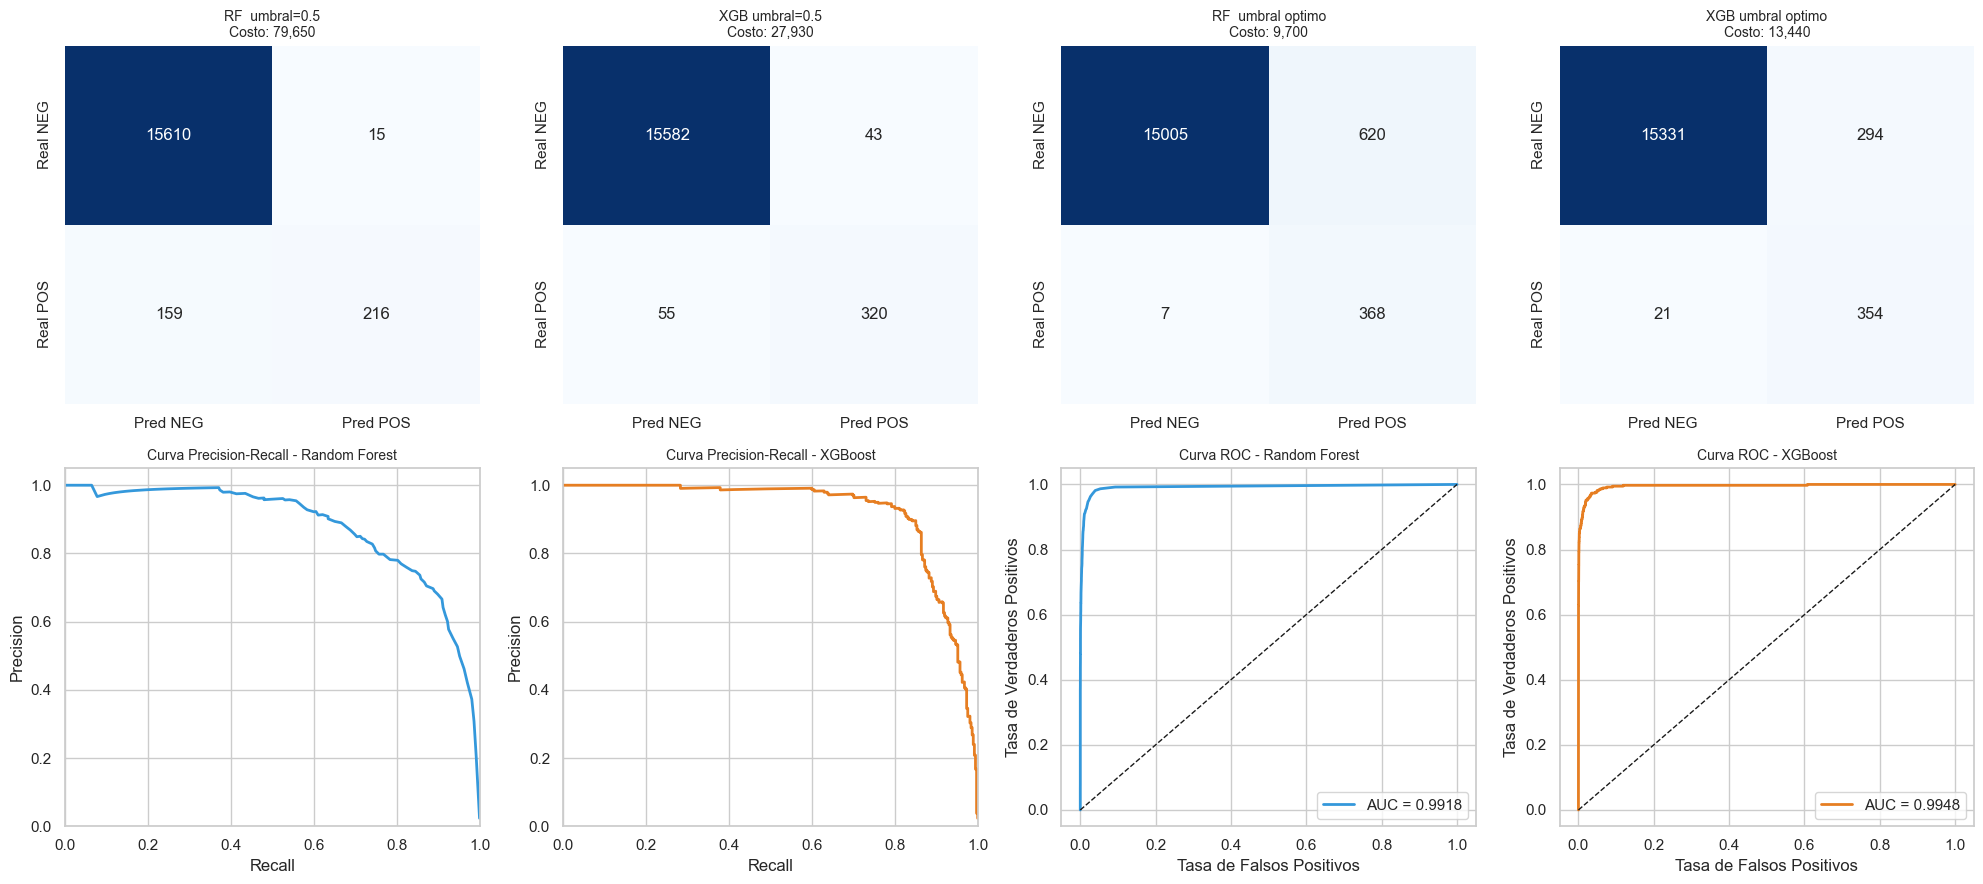

Grafico guardado en outputs/


In [8]:
# ============================================================
# BLOQUE 8: Matrices de confusion y curvas Precision-Recall
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(20, 9))

modelos = [
    ("RF  umbral=0.5",    res_rf_default),
    ("XGB umbral=0.5",    res_xgb_default),
    ("RF  umbral optimo", res_rf_opt),
    ("XGB umbral optimo", res_xgb_opt),
]

# --- Matrices de confusion ---
for i, (titulo, res) in enumerate(modelos):
    cm = np.array([[res['tn'], res['fp']],
                   [res['fn'], res['tp']]])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred NEG', 'Pred POS'],
                yticklabels=['Real NEG', 'Real POS'],
                ax=axes[0, i], cbar=False)
    axes[0, i].set_title(f"{titulo}\nCosto: {res['costo']:,}", fontsize=10)

# --- Curvas Precision-Recall ---
for i, (nombre, prob, color) in enumerate([
    ("Random Forest", prob_rf,  '#3498db'),
    ("XGBoost",       prob_xgb, '#e67e22')
]):
    prec_c, rec_c, thresh = precision_recall_curve(y_test, prob)
    axes[1, i].plot(rec_c, prec_c, color=color, linewidth=2)
    axes[1, i].set_xlabel('Recall')
    axes[1, i].set_ylabel('Precision')
    axes[1, i].set_title(f'Curva Precision-Recall - {nombre}', fontsize=10)
    axes[1, i].set_xlim([0, 1])
    axes[1, i].set_ylim([0, 1.05])

# --- Curvas ROC ---
for i, (nombre, prob, color) in enumerate([
    ("Random Forest", prob_rf,  '#3498db'),
    ("XGBoost",       prob_xgb, '#e67e22')
]):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    axes[1, i+2].plot(fpr, tpr, color=color, linewidth=2,
                      label=f'AUC = {auc_val:.4f}')
    axes[1, i+2].plot([0,1], [0,1], 'k--', linewidth=1)
    axes[1, i+2].set_xlabel('Tasa de Falsos Positivos')
    axes[1, i+2].set_ylabel('Tasa de Verdaderos Positivos')
    axes[1, i+2].set_title(f'Curva ROC - {nombre}', fontsize=10)
    axes[1, i+2].legend(loc='lower right')

plt.tight_layout()
plt.savefig('../outputs/05_evaluacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico guardado en outputs/")

In [9]:
# ============================================================
# BLOQUE 9: Guardado de modelos
# ============================================================

import joblib
import os

os.makedirs('../models', exist_ok=True)

joblib.dump(rf_model,  '../models/random_forest.pkl')
joblib.dump(xgb_model, '../models/xgboost.pkl')

# Guardar tambien los umbrales optimos y probabilidades
resultados = {
    'umbral_opt_rf'    : umbral_opt_rf,
    'umbral_opt_xgb'   : umbral_opt_xgb,
    'umbral_teorico'   : umbral_teorico,
    'prob_rf'          : prob_rf,
    'prob_xgb'         : prob_xgb,
    'res_rf_default'   : res_rf_default,
    'res_xgb_default'  : res_xgb_default,
    'res_rf_opt'       : res_rf_opt,
    'res_xgb_opt'      : res_xgb_opt,
}

joblib.dump(resultados, '../models/resultados_modelos.pkl')

print("Modelos guardados en models/")
print("   random_forest.pkl")
print("   xgboost.pkl")
print("   resultados_modelos.pkl")

Modelos guardados en models/
   random_forest.pkl
   xgboost.pkl
   resultados_modelos.pkl
